<a href="https://colab.research.google.com/github/gmauricio-toledo/math-ML/blob/main/Notebooks/10-Reducci%C3%B3n_de_dimensionalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maldición de la dimensionalidad

La maldición de la dimensionalidad es un fenómeno fundamental que emerge cuando trabajamos con espacios de alta dimensión, donde las intuiciones geométricas desarrolladas en dimensiones bajas fallan.

Conforme aumenta la dimensión del espacio, las distancias entre puntos tienden a volverse uniformemente grandes, los volúmenes se concentran en las esquinas de los hipercubos, y los algoritmos que dependen de nociones de proximidad pierden su eficacia. Este comportamiento contraintuitivo plantea desafíos en áreas como el análisis de datos, la optimización, y el aprendizaje automático, donde frecuentemente debemos trabajar con espacios de dimensión muy grande. L


En este experimento generaremos puntos aleatorios en espacios de diferentes dimensiones y calcularemos las distancias euclidianas entre ellos. Conforme aumenta la dimensionalidad, observaremos cómo todas las distancias tienden a volverse muy similares entre sí, perdiendo la capacidad de discriminar entre puntos "cercanos" y "lejanos". Este fenómeno, conocido como la maldición de la dimensionalidad, explica por qué muchos algoritmos de machine learning (como k-NN o clustering) pierden efectividad en espacios de alta dimensión.


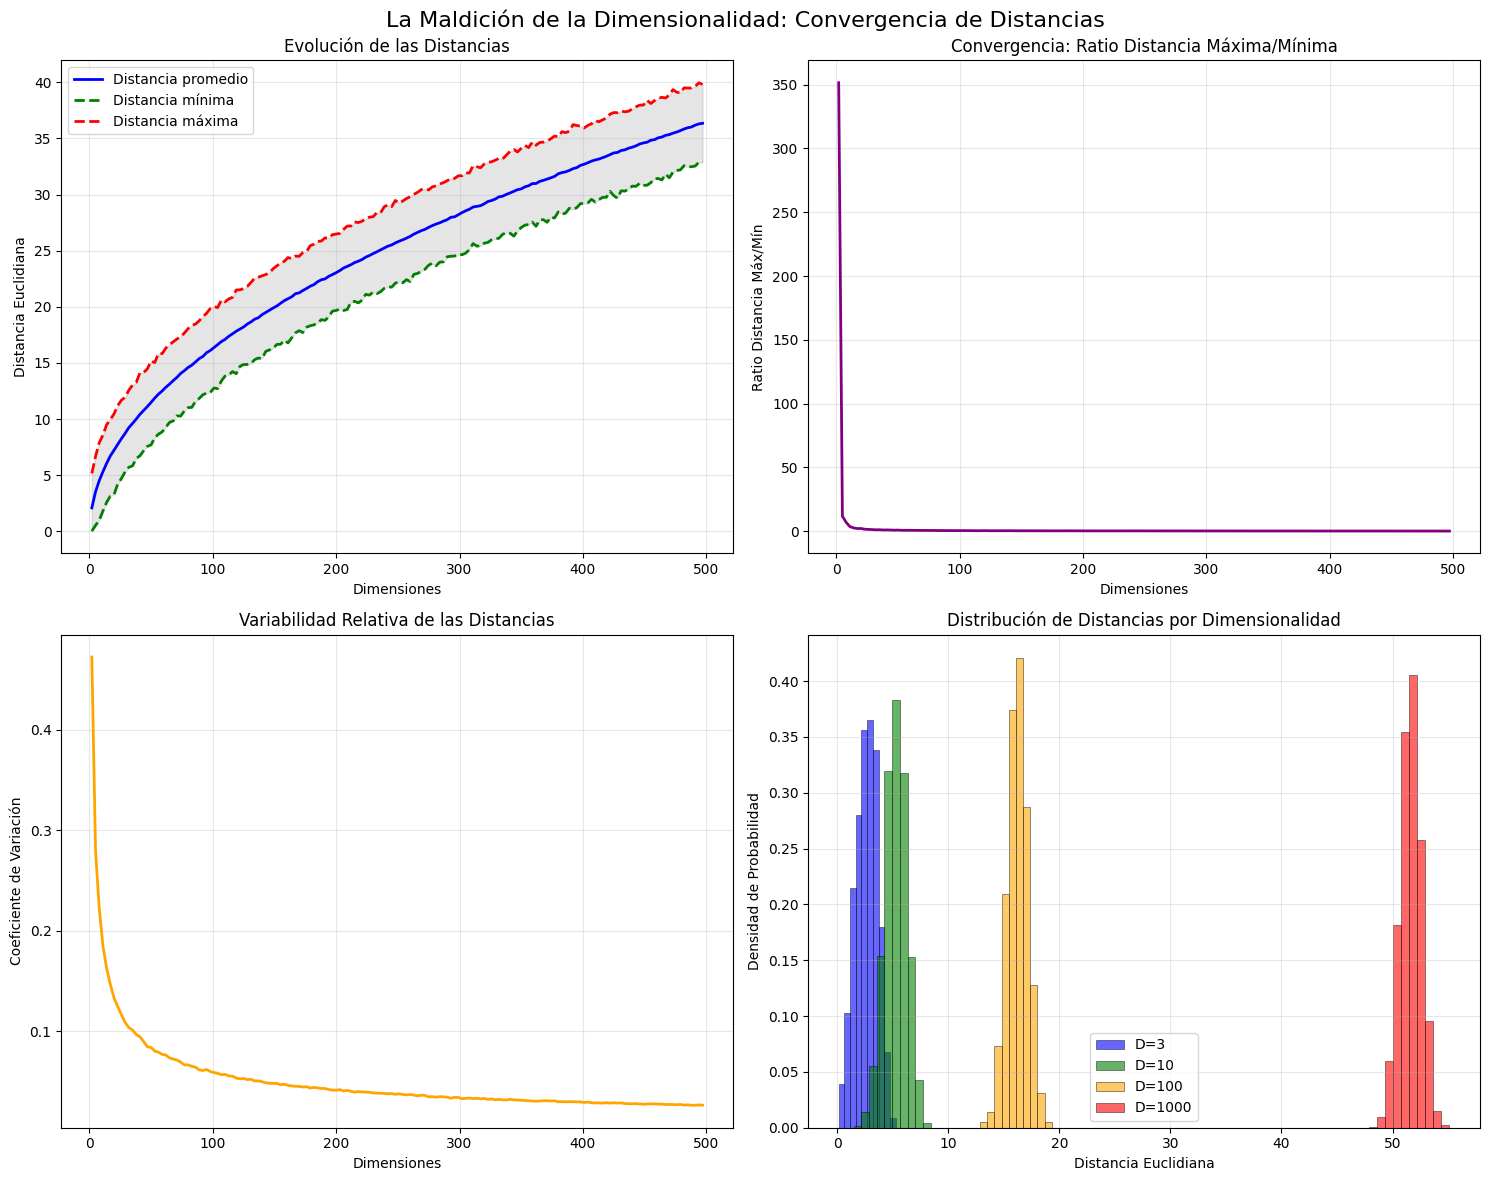

In [ ]:
#@title Experimento maldición de la dimensionalidad
import numpy as np
# from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

side = 2  # Longitud del lado del hipercubo
n_puntos = 100
dims = list(range(2, 500, 3))
n_repetitions = 5  # Repeticiones por cada experimento

average_distances = []
min_distances = []
max_distances = []
std_distances = []
relative_std = []  # Desviación estándar relativa

for i, dim in enumerate(dims):
    exp_avg, exp_min, exp_max, exp_std = [], [], [], []  # Resultados promedio de cada experimento

    for _ in range(n_repetitions):
        puntos = np.random.uniform(size=(n_puntos, dim), low=-side, high=side)
        distances = pdist(puntos, metric='euclidean')

        exp_avg.append(np.mean(distances))
        exp_min.append(np.min(distances))
        exp_max.append(np.max(distances))
        exp_std.append(np.std(distances))

    # Promediar los experimentos
    avg_dist = np.mean(exp_avg)
    average_distances.append(avg_dist)
    min_distances.append(np.mean(exp_min))
    max_distances.append(np.mean(exp_max))
    std_distances.append(np.mean(exp_std))

    # Coeficiente de variación (desviación estándar relativa)
    relative_std.append(np.mean(exp_std) / avg_dist)


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('La Maldición de la Dimensionalidad: Convergencia de Distancias', fontsize=16)

# 1. Distancias absolutas:
ax1.plot(dims, average_distances, 'b-', linewidth=2, label='Distancia promedio')
ax1.plot(dims, min_distances, 'g--', linewidth=2, label='Distancia mínima')
ax1.plot(dims, max_distances, 'r--', linewidth=2, label='Distancia máxima')
ax1.fill_between(dims, min_distances, max_distances, alpha=0.2, color='gray')
ax1.set_xlabel('Dimensiones')
ax1.set_ylabel('Distancia Euclidiana')
ax1.set_title('Evolución de las Distancias')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Razón máximo/mínimo:
ratio_max_min = (np.array(max_distances) - np.array(min_distances) )/ np.array(min_distances)
ax2.plot(dims, ratio_max_min, 'purple', linewidth=2)
ax2.set_xlabel('Dimensiones')
ax2.set_ylabel('Ratio Distancia Máx/Mín')
ax2.set_title('Convergencia: Ratio Distancia Máxima/Mínima')
ax2.grid(True, alpha=0.3)

# 3. Coeficiente de variación:
ax3.plot(dims, relative_std, 'orange', linewidth=2)
ax3.set_xlabel('Dimensiones')
ax3.set_ylabel('Coeficiente de Variación')
ax3.set_title('Variabilidad Relativa de las Distancias')
ax3.grid(True, alpha=0.3)

# 4. Distribución de distancias para dimensiones específicas
sample_dims = [3, 10, 100, 1000]
colors = ['blue', 'green', 'orange', 'red']

for dim, color in zip(sample_dims, colors):
    puntos_sample = np.random.uniform(size=(n_puntos, dim), low=-side, high=side)
    distances_sample = pdist(puntos_sample, metric='euclidean')
    ax4.hist(distances_sample,alpha=0.6, color=color,edgecolor='black',
            label=f'D={dim}', density=True, linewidth=0.5)

ax4.set_xlabel('Distancia Euclidiana')
ax4.set_ylabel('Densidad de Probabilidad')
ax4.set_title('Distribución de Distancias por Dimensionalidad')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




In [ ]:
#@title Creación de datos

import numpy as np
import cv2
from tensorflow.keras.datasets import mnist

# 1. Cargar el dataset MNIST y obtener una imagen del número '3'
(x_train, y_train), _ = mnist.load_data()
idx_tres = np.where(y_train == 3)[0][0]
imagen_base = x_train[idx_tres] # Matriz original de 28x28

# 2. Configuración de parámetros
N_VARIACIONES = 1000
ALTO_CANVAS, ANCHO_CANVAS = 100, 100
RANGO_ROTACION = (-30, 30)       # Grados de rotación
RANGO_TRASLACION = (-20, 20)     # Desplazamiento en píxeles (dx, dy)

# Inicializar la matriz final de (1000, 10000)
matriz_imagenes = np.zeros((N_VARIACIONES, ALTO_CANVAS * ANCHO_CANVAS), dtype=np.float32)

# Crear un lienzo negro de 100x100 e insertar la imagen de 28x28 en el centro
canvas_centrado = np.zeros((ALTO_CANVAS, ANCHO_CANVAS), dtype=np.uint8)
offset_y = (ALTO_CANVAS - 28) // 2
offset_x = (ANCHO_CANVAS - 28) // 2
canvas_centrado[offset_y:offset_y+28, offset_x:offset_x+28] = imagen_base

centro_canvas = (ANCHO_CANVAS // 2, ALTO_CANVAS // 2)

# 3. Generar las 1000 variaciones
np.random.seed(42)  # Para reproducibilidad

for i in range(N_VARIACIONES):
    # Generar parámetros aleatorios
    angulo = np.random.uniform(*RANGO_ROTACION)
    dx = np.random.uniform(*RANGO_TRASLACION)
    dy = np.random.uniform(*RANGO_TRASLACION)

    # Matriz de rotación respecto al centro del lienzo
    M_rot = cv2.getRotationMatrix2D(centro_canvas, angulo, scale=1.0)

    # Añadir la traslación (dx, dy) a la matriz afín
    M_rot[0, 2] += dx
    M_rot[1, 2] += dy

    # Aplicar la transformación
    imagen_transformada = cv2.warpAffine(
        canvas_centrado,
        M_rot,
        (ANCHO_CANVAS, ALTO_CANVAS),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    # Normalizar valores de píxeles [0.0, 1.0] y aplanar a vector de 10000
    matriz_imagenes[i] = (imagen_transformada / 255.0).flatten()

print("Forma de la matriz resultante:", matriz_imagenes.shape)
# Salida esperada: (1000, 10000)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Forma de la matriz resultante: (1000, 10000)


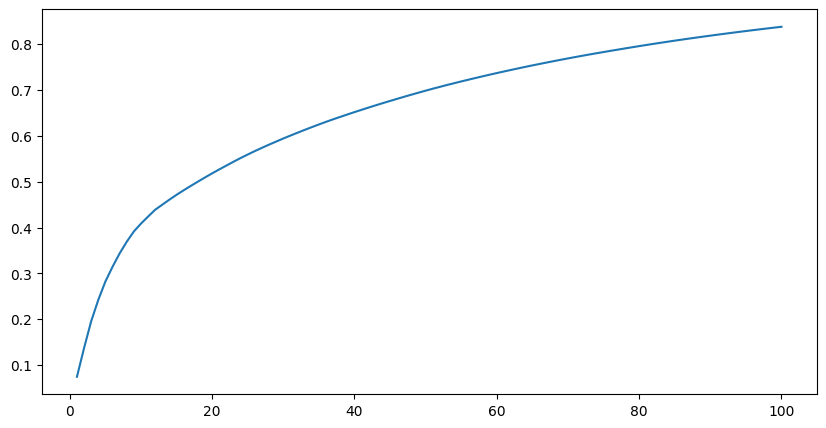

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA(n_components=100)
pca.fit(matriz_imagenes)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada)
plt.show(9)

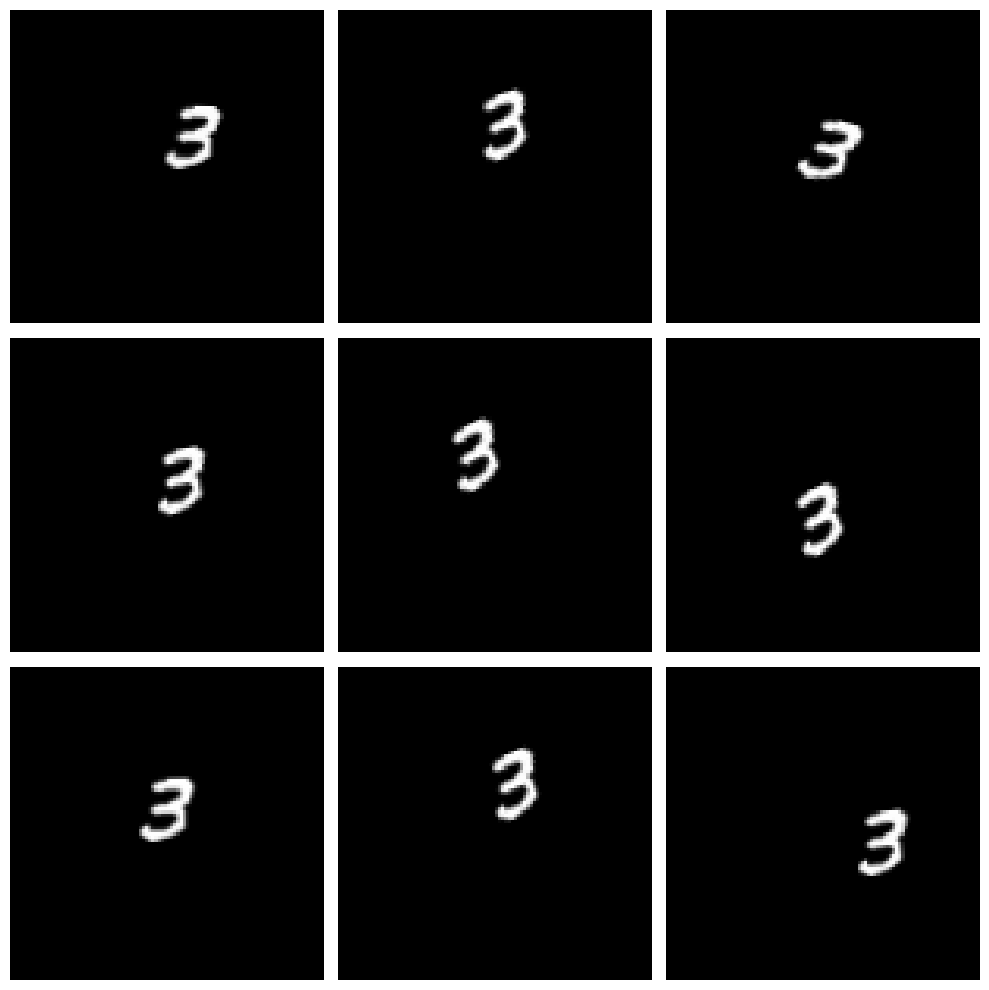

In [ ]:
random_idxs = np.random.choice(matriz_imagenes.shape[0], size=9, replace=False)

fig, axs = plt.subplots(3, 3, figsize=(10, 10))
for i, idx in enumerate(random_idxs):
    img = matriz_imagenes[idx].reshape(ALTO_CANVAS, ANCHO_CANVAS)
    axs[i // 3, i % 3].imshow(img, cmap='gray')
    axs[i // 3, i % 3].axis('off')
plt.tight_layout()
plt.show()


Calculando proyecciones Isomap, esto puede tomar unos segundos...


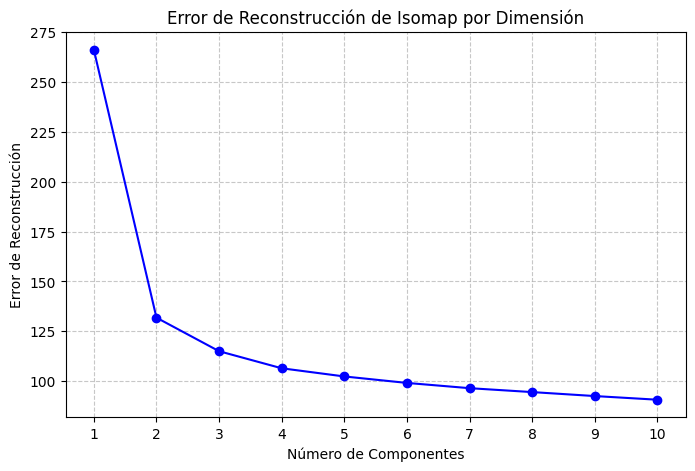

In [ ]:
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt

# Probar proyecciones desde 1 hasta 10 dimensiones
dimensiones = range(1, 11)
errores = []

for d in dimensiones:
    # n_neighbors define el radio de conexión para trazar la variedad
    iso = Isomap(n_components=d, n_neighbors=20)
    iso.fit(matriz_imagenes)

    # Extraer el error de reconstrucción de la proyección
    errores.append(iso.reconstruction_error())

# Graficar el resultado
plt.figure(figsize=(8, 5))
plt.plot(dimensiones, errores, marker='o', linestyle='-', color='b')
plt.title('Error de Reconstrucción de Isomap por Dimensión')
plt.xlabel('Número de Componentes')
plt.ylabel('Error de Reconstrucción')
plt.xticks(dimensiones)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.13/dist-packages/matplotlib/pyplot.py'>

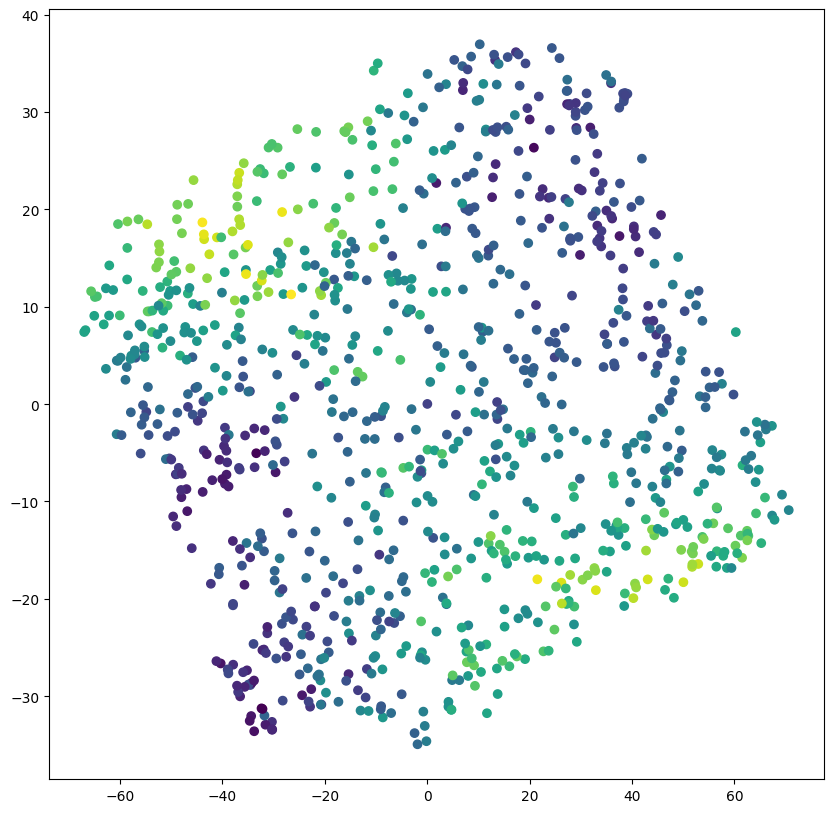

In [ ]:
proyeccion_isomap = Isomap(n_components=3, n_neighbors=15).fit_transform(matriz_imagenes)

plt.figure(figsize=(10, 10))
plt.scatter(proyeccion_isomap[:, 0], proyeccion_isomap[:, 1], c=proyeccion_isomap[:, 2], cmap='viridis')
plt.whow()